# LLM Comparison

This notebook analyzes the results of three models (gpt-5.1, claude-sonnet-4.5 and DeepSeek-R1-mga) in molecule optimization experiments:

**Task**
- Number of random pubchem molecules: 20
- Min similarity: 0.7
- Min QED: 0.7
- Target score: 0.9
- Max iterations: 51
- Temperature: 0.0
- Repetitions per molecule: 1

additionally two different XAI (explanation) settings:
- **Full XAI**: Complete explanations for all oracles
- **No XAI**: No explanations provided

In [21]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# Define paths
RESULTS_DIR = Path("../data/results/similarity_qed_pubchem")

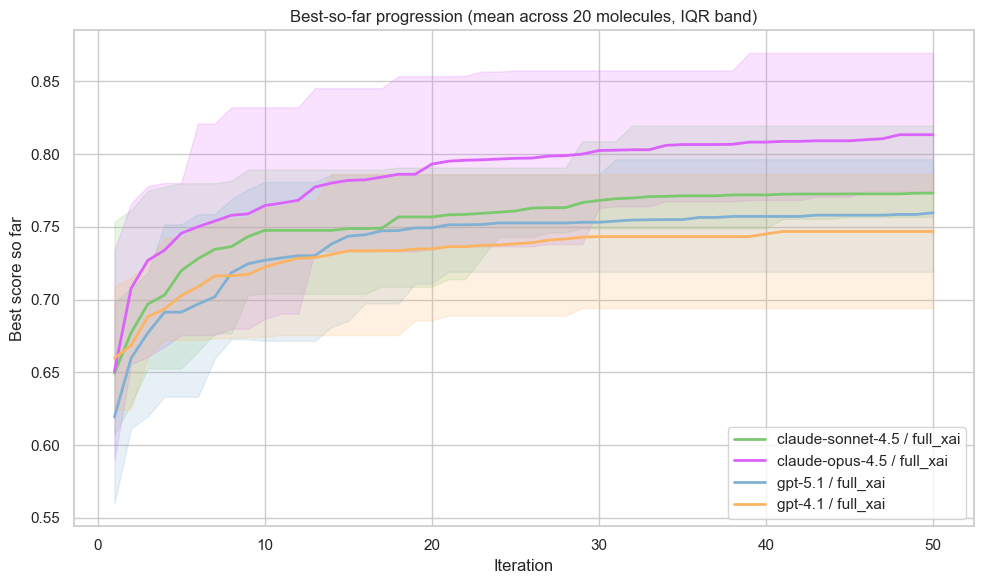

In [32]:

GROUPS = [
    ("claude-sonnet-4.5", "full_xai",   "claude-sonnet-4.5_full_xai"),
    #("claude-sonnet-4.5", "no_xai", "claude-sonnet-4.5_no_xai"),
    ("claude-opus-4.5", "full_xai",   "claude-opus-4.5_full_xai"),
    #("claude-opus-4.5", "no_xai",   "claude-opus-4.5_no_xai"),
    ("gpt-5.1", "full_xai",   "gpt-5.1_full_xai"),
    #("gpt-5.1", "no_xai", "gpt-5.1_no_xai"),
    ("gpt-4.1", "full_xai",   "gpt-4.1_full_xai"),
    #("gpt-4.1", "no_xai", "gpt-4.1_no_xai"),
    #("DeepSeek-R1-mga", "full_xai",   "DeepSeek-R1-mga_full_xai"),
]

# Light/dark pairs per model (x, nox). Change if you want different hues.
COLORS = {
    "claude-sonnet-4.5": ("#7bc96f", "#1b7837"),  # light/dark green
    "gpt-5.1": ("#80b1d3", "#1f78b4"),  # light/dark blue
    "gpt-4.1": ("#fdb462", "#e66101"),  # light/dark orange
    "claude-opus-4.5": ("#db62fd", "#8701e6"),  # light/dark orange
}

def load_trace(p):
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d  # supports {"trace":[...]} or [...]

def best_so_far(trace):
    by_it = defaultdict(list)
    for e in trace:
        by_it[int(e["iteration"])].append(float(e["score"]))
    its = sorted(by_it)
    out, best = {}, None
    for it in its:
        it_best = max(by_it[it])  # higher is better
        best = it_best if best is None else max(best, it_best)
        out[it] = best
    return out

def align(curve, its):
    vals, last, seen = [], np.nan, False
    for it in its:
        if it in curve:
            last, seen = curve[it], True
        vals.append(last if seen else np.nan)
    return np.array(vals, float)

# load all curves, build global iteration axis
raw, all_its = {}, set()
for model, mode, folder in GROUPS:
    files = sorted((RESULTS_DIR / folder).glob("sim_qed_pubchem_*.json"))
    if not files:
        raise FileNotFoundError(f"No files in {RESULTS_DIR/folder} matching sim_qed_pubchem_*.json")
    curves = [best_so_far(load_trace(f)) for f in files]
    raw[(model, mode)] = curves
    for c in curves: all_its.update(c.keys())

its = sorted(all_its)

plt.figure()
for model, mode, _ in GROUPS:
    runs = np.vstack([align(c, its) for c in raw[(model, mode)]])  # (n_runs, n_its)
    mean = np.nanmean(runs, axis=0)
    lo, hi = np.nanpercentile(runs, [25, 75], axis=0)  # IQR as "variance band"
    color = COLORS[model][0 if mode == "full_xai" else 1]
    plt.fill_between(its, lo, hi, alpha=0.18, color=color)
    plt.plot(its, mean, lw=2, color=color, label=f"{model} / {mode}")

# Add target score line
#plt.axhline(y=0.9, color='gray', linestyle='--', linewidth=1.5, label=f'Target ({0.9})')
    

plt.xlabel("Iteration")
plt.ylabel("Best score so far")
plt.title("Best-so-far progression (mean across 20 molecules, IQR band)")
plt.legend()
plt.tight_layout()
plt.show()
